In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/alzheimers-detection-working/MedViTV2-main
!pip install -r requirements.txt
!pip install "natten==0.21.5+torch2100cu128" -f https://whl.natten.org
!pip install grad-cam

/content/alzheimers-detection-working/MedViTV2-main
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 70.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━

In [ ]:
from pathlib import Path

path = Path("/content/alzheimers-detection-working/MedViTV2-main/MedViT.py")
backup_path = Path("/content/alzheimers-detection-working/MedViTV2-main/MedViT_backup.py")

if not backup_path.exists():
    backup_path.write_text(path.read_text())

text = path.read_text()

text = text.replace("attn_drop=drop,", "")
text = text.replace("attn_drop=attn_drop,", "")
text = text.replace(
    'extra_args = {"rel_pos_bias": True} if is_natten_post_017 else {"bias": True}',
    'extra_args = {}'
)

path.write_text(text)
print("Patched MedViT.py for current Colab/NATTEN compatibility.")

Patched MedViT.py for current Colab/NATTEN compatibility.


In [ ]:
import importlib.util
import sys
import os

repo_dir = "/content/alzheimers-detection-working/MedViTV2-main"
fasterkan_path = os.path.join(repo_dir, "fasterkan.py")
medvit_path = os.path.join(repo_dir, "MedViT.py")

# Load fasterkan first
spec_fk = importlib.util.spec_from_file_location("fasterkan", fasterkan_path)
fasterkan = importlib.util.module_from_spec(spec_fk)
sys.modules["fasterkan"] = fasterkan
spec_fk.loader.exec_module(fasterkan)

# Then load MedViT
spec_mv = importlib.util.spec_from_file_location("MedViT", medvit_path)
MedViT = importlib.util.module_from_spec(spec_mv)
sys.modules["MedViT"] = MedViT
spec_mv.loader.exec_module(MedViT)

from MedViT import MedViT_small

print("Imported MedViT_small successfully.")

Imported MedViT_small successfully.


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

CLASS_NAMES = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
nb_classes = len(CLASS_NAMES)

model = MedViT_small(num_classes=nb_classes).to(device)

checkpoint_path = "/content/drive/MyDrive/alzheimers_checkpoints/MedViT_small_Dementia.pth"
print("Checkpoint exists:", os.path.exists(checkpoint_path))

checkpoint = torch.load(checkpoint_path, map_location=device)
state_dict = checkpoint['model'] if isinstance(checkpoint, dict) and 'model' in checkpoint else checkpoint

# Drop incompatible relative position bias keys
filtered_state_dict = {
    k: v for k, v in state_dict.items()
    if not k.endswith(".attn.rpb")
}

missing, unexpected = model.load_state_dict(filtered_state_dict, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()
print("Model loaded successfully.")

Device: cpu
initialize_weights...
Checkpoint exists: True
Missing keys: []
Unexpected keys: []
Model loaded successfully.


In [ ]:
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

test_dir = "/content/drive/MyDrive/Software SP26 Alzheimer's Detection/processed_data/test"
print("Classes in test_dir:", sorted(os.listdir(test_dir)))

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

Classes in test_dir: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


Using image: /content/drive/MyDrive/Software SP26 Alzheimer's Detection/processed_data/test/MildDemented/82dd4d63-13db-4216-b3a0-087f42cd2b57.jpg


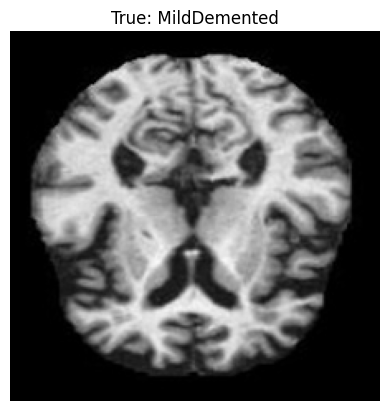

/usr/local/lib/python3.12/dist-packages/torch/nn/attention/flex_attention.py:1559: FutureWarning: return_lse is deprecated and will be removed in v2.10. Please use return_aux=AuxRequest(lse=True) instead.
  _warn_once(
/usr/local/lib/python3.12/dist-packages/torch/nn/attention/flex_attention.py:1624: UserWarning: flex_attention called without torch.compile() - this will use an unfused implementation that materializes the full scores matrix instead of generating a fused kernel.

SOLUTION: Use torch.compile(flex_attention)(...)

If you want to debug your score_mod/mask_mod, you can set:
torch.nn.attention.flex_attention._FLEX_ATTENTION_DISABLE_COMPILE_DEBUG = True

This will allow you to use print statements or breakpoints. Note: This doesn't work with the backwards pass and may produce incorrect results.
  _warn_once(


Predicted: MildDemented
Confidence: 0.9999995231628418


In [ ]:
sample_class = "MildDemented"
sample_folder = os.path.join(test_dir, sample_class)
sample_image_path = os.path.join(sample_folder, os.listdir(sample_folder)[0])

print("Using image:", sample_image_path)

img = Image.open(sample_image_path).convert("RGB")
plt.imshow(img)
plt.title(f"True: {sample_class}")
plt.axis("off")
plt.show()

input_tensor = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    probs = torch.softmax(output, dim=1)

pred_idx = probs.argmax(dim=1).item()
confidence = probs[0, pred_idx].item()

print("Predicted:", CLASS_NAMES[pred_idx])
print("Confidence:", confidence)

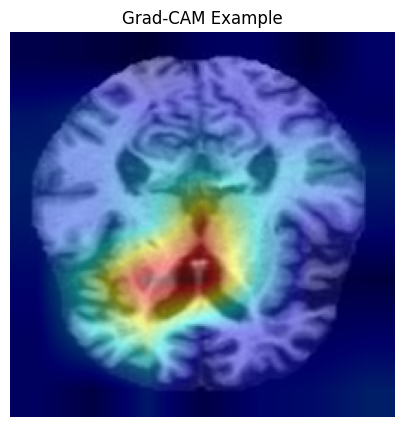

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2

target_layers = [model.norm]
cam = GradCAM(model=model, target_layers=target_layers)

rgb_img = np.array(img.resize((224, 224))).astype(np.float32) / 255.0
grayscale_cam = cam(input_tensor=input_tensor)[0]
cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True, image_weight=0.6)

plt.figure(figsize=(5, 5))
plt.imshow(cam_image)
plt.title("Grad-CAM Example")
plt.axis("off")
plt.show()

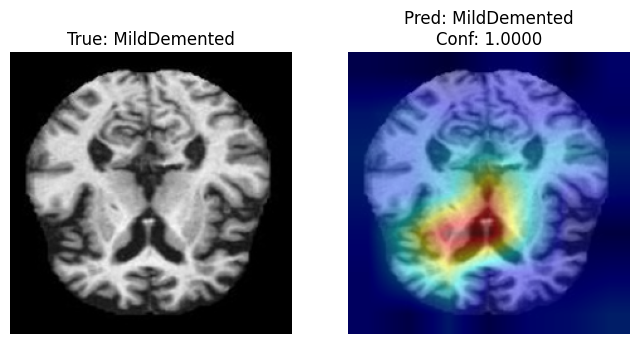

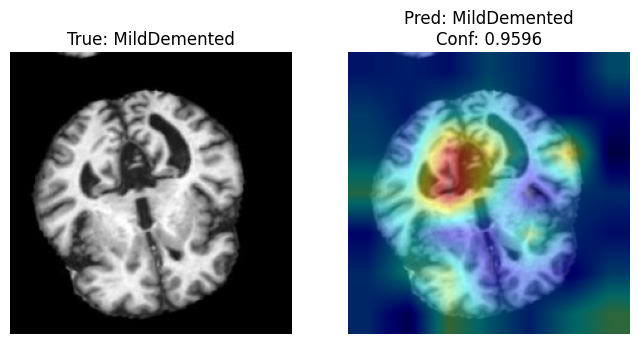

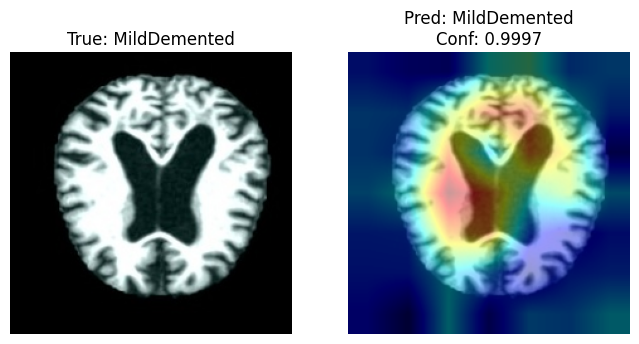

In [ ]:
sample_class = "MildDemented"
sample_folder = os.path.join(test_dir, sample_class)
image_files = os.listdir(sample_folder)[:3]

target_layers = [model.norm]
cam = GradCAM(model=model, target_layers=target_layers)

for fname in image_files:
    img_path = os.path.join(sample_folder, fname)
    img = Image.open(img_path).convert("RGB")

    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = probs.argmax(dim=1).item()
        confidence = probs[0, pred_idx].item()

    rgb_img = np.array(img.resize((224, 224))).astype(np.float32) / 255.0
    grayscale_cam = cam(input_tensor=input_tensor)[0]
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True, image_weight=0.6)

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img, cmap="gray")
    plt.title(f"True: {sample_class}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cam_image)
    plt.title(f"Pred: {CLASS_NAMES[pred_idx]}\nConf: {confidence:.4f}")
    plt.axis("off")

    plt.show()

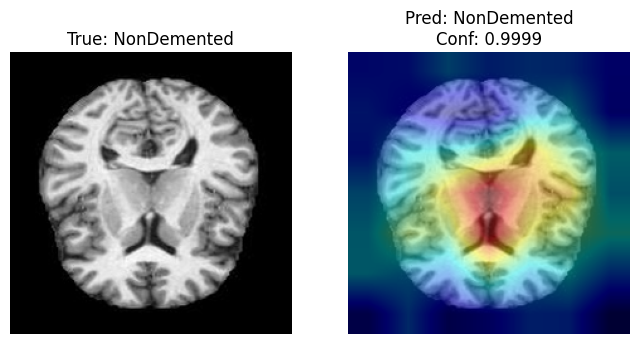

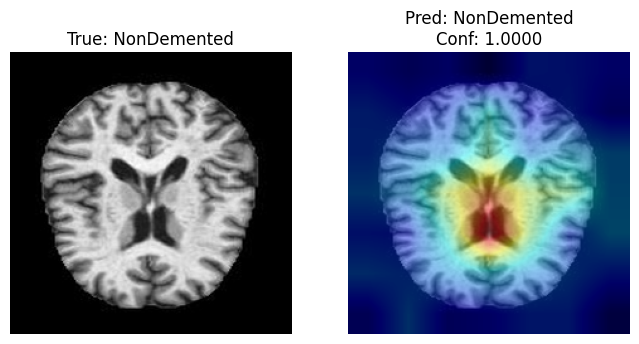

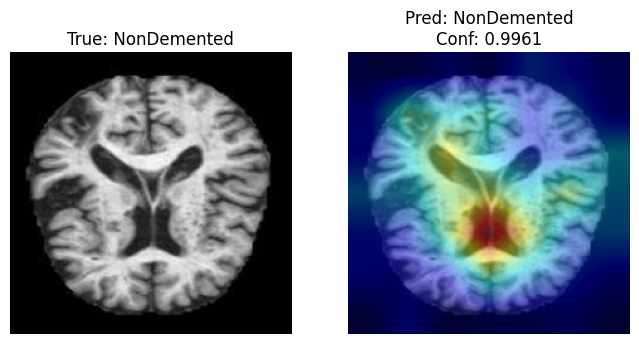

In [ ]:
sample_class = "NonDemented"
sample_folder = os.path.join(test_dir, sample_class)
image_files = os.listdir(sample_folder)[:3]

target_layers = [model.norm]
cam = GradCAM(model=model, target_layers=target_layers)

for fname in image_files:
    img_path = os.path.join(sample_folder, fname)
    img = Image.open(img_path).convert("RGB")

    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = probs.argmax(dim=1).item()
        confidence = probs[0, pred_idx].item()

    rgb_img = np.array(img.resize((224, 224))).astype(np.float32) / 255.0
    grayscale_cam = cam(input_tensor=input_tensor)[0]
    cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True, image_weight=0.6)

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img, cmap="gray")
    plt.title(f"True: {sample_class}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cam_image)
    plt.title(f"Pred: {CLASS_NAMES[pred_idx]}\nConf: {confidence:.4f}")
    plt.axis("off")

    plt.show()

In [ ]:
output_dir = "/content/alzheimers-detection-working/MedViTV2-main/Heatmap/gradcam_outputs"
os.makedirs(output_dir, exist_ok=True)

classes_to_run = ["MildDemented", "NonDemented"]

target_layers = [model.norm]
cam = GradCAM(model=model, target_layers=target_layers)

for sample_class in classes_to_run:
    sample_folder = os.path.join(test_dir, sample_class)
    image_files = os.listdir(sample_folder)[:3]

    for fname in image_files:
        img_path = os.path.join(sample_folder, fname)
        img = Image.open(img_path).convert("RGB")

        input_tensor = transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probs = torch.softmax(output, dim=1)
            pred_idx = probs.argmax(dim=1).item()
            confidence = probs[0, pred_idx].item()

        rgb_img = np.array(img.resize((224, 224))).astype(np.float32) / 255.0
        grayscale_cam = cam(input_tensor=input_tensor)[0]
        cam_image = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True, image_weight=0.6)

        fig = plt.figure(figsize=(8, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(rgb_img, cmap="gray")
        plt.title(f"True: {sample_class}")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(cam_image)
        plt.title(f"Pred: {CLASS_NAMES[pred_idx]}\nConf: {confidence:.4f}")
        plt.axis("off")

        save_name = f"{sample_class}_{os.path.splitext(fname)[0]}_gradcam.png"
        save_path = os.path.join(output_dir, save_name)
        plt.tight_layout()
        plt.savefig(save_path, dpi=150)
        plt.close(fig)

print("Saved Grad-CAM outputs to:", output_dir)

Saved Grad-CAM outputs to: /content/alzheimers-detection-working/MedViTV2-main/Heatmap/gradcam_outputs


In [ ]:
import os

path = "/content/alzheimers-detection-working/MedViTV2-main/Tutorials"
print(os.listdir(path))

['Visualization.ipynb', 'Visualization_Alzheimers.ipynb', '.ipynb_checkpoints', 'Evaluation.ipynb']
